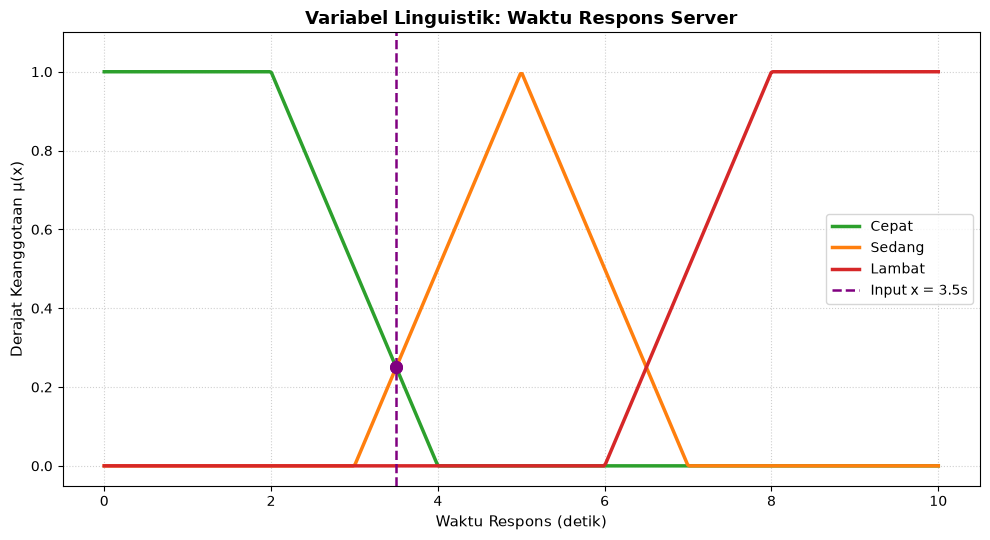

Hasil Fuzzifikasi untuk x = 3.5 detik:
 - Cepat   : 0.25
 - Sedang  : 0.25
 - Lambat  : 0.0


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# 1. DEFINISI FUNGSI KEANGGOTAAN LINGUISTIK
# ==========================================================
def mf_cepat(x):
    """Fungsi bahu kiri untuk label Cepat"""
    kondisi = [
        x <= 2.0,
        (x > 2.0) & (x < 4.0),
        x >= 4.0
    ]
    pilihan = [
        1.0,
        (4.0 - x) / (4.0 - 2.0),
        0.0
    ]
    return np.select(kondisi, pilihan)


def mf_sedang(x):
    """Fungsi segitiga untuk label Sedang"""
    kondisi = [
        (x <= 3.0) | (x >= 7.0),
        (x > 3.0) & (x <= 5.0),
        (x > 5.0) & (x < 7.0)
    ]
    pilihan = [
        0.0,
        (x - 3.0) / (5.0 - 3.0),
        (7.0 - x) / (7.0 - 5.0)
    ]
    return np.select(kondisi, pilihan)


def mf_lambat(x):
    """Fungsi bahu kanan untuk label Lambat"""
    kondisi = [
        x <= 6.0,
        (x > 6.0) & (x < 8.0),
        x >= 8.0
    ]
    pilihan = [
        0.0,
        (x - 6.0) / (8.0 - 6.0),
        1.0
    ]
    return np.select(kondisi, pilihan)


# ==========================================================
# 2. DEFINISI STRUKTUR VARIABEL LINGUISTIK
# ==========================================================
variabel_waktu_respons = {
    "nama": "Waktu Respons Server",
    "satuan": "detik",
    "semesta": (0.0, 10.0),
    "label": {
        "Cepat": mf_cepat,
        "Sedang": mf_sedang,
        "Lambat": mf_lambat
    }
}


# ==========================================================
# 3. FUNGSI FUZZIFIKASI INPUT TUNGGAL
# ==========================================================
def fuzzifikasi(nilai_crisp, variabel):
    """
    Melakukan pemetaan nilai crisp ke semua derajat label linguistik.
    """
    hasil = {}
    u_min, u_max = variabel["semesta"]
    
    if not (u_min <= nilai_crisp <= u_max):
        raise ValueError(f"Input {nilai_crisp} di luar semesta [{u_min}, {u_max}]")
        
    for nama_label, fungsi_mf in variabel["label"].items():
        derajat = float(fungsi_mf(np.array([nilai_crisp]))[0])
        hasil[nama_label] = round(derajat, 4)
        
    return hasil


# ==========================================================
# 4. PENGUJIAN DAN VISUALISASI
# ==========================================================
x_semesta = np.linspace(0.0, 10.0, 500)

y_cepat = mf_cepat(x_semesta)
y_sedang = mf_sedang(x_semesta)
y_lambat = mf_lambat(x_semesta)

plt.figure(figsize=(10, 5.5))
plt.plot(x_semesta, y_cepat, label='Cepat', color='#2ca02c', linewidth=2.5)
plt.plot(x_semesta, y_sedang, label='Sedang', color='#ff7f0e', linewidth=2.5)
plt.plot(x_semesta, y_lambat, label='Lambat', color='#d62728', linewidth=2.5)

# Simulasi input x = 3.5 detik
x_uji = 3.5
derajat_uji = fuzzifikasi(x_uji, variabel_waktu_respons)

plt.axvline(x=x_uji, color='purple', linestyle='--', linewidth=1.8, label=f'Input x = {x_uji}s')
plt.scatter([x_uji, x_uji], [derajat_uji['Cepat'], derajat_uji['Sedang']], 
            color='purple', s=70, zorder=5)

plt.title(f'Variabel Linguistik: {variabel_waktu_respons["nama"]}', fontsize=13, fontweight='bold')
plt.xlabel(f'Waktu Respons ({variabel_waktu_respons["satuan"]})', fontsize=11)
plt.ylabel('Derajat Keanggotaan μ(x)', fontsize=11)
plt.ylim(-0.05, 1.1)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='center right', fontsize=10)
plt.tight_layout()

plt.savefig('variabel_linguistik_waktu_respons.png', dpi=300)
plt.show()

# Tampilkan hasil terminal
print(f"Hasil Fuzzifikasi untuk x = {x_uji} {variabel_waktu_respons['satuan']}:")
for label, deg in derajat_uji.items():
    print(f" - {label:<8}: {deg}")

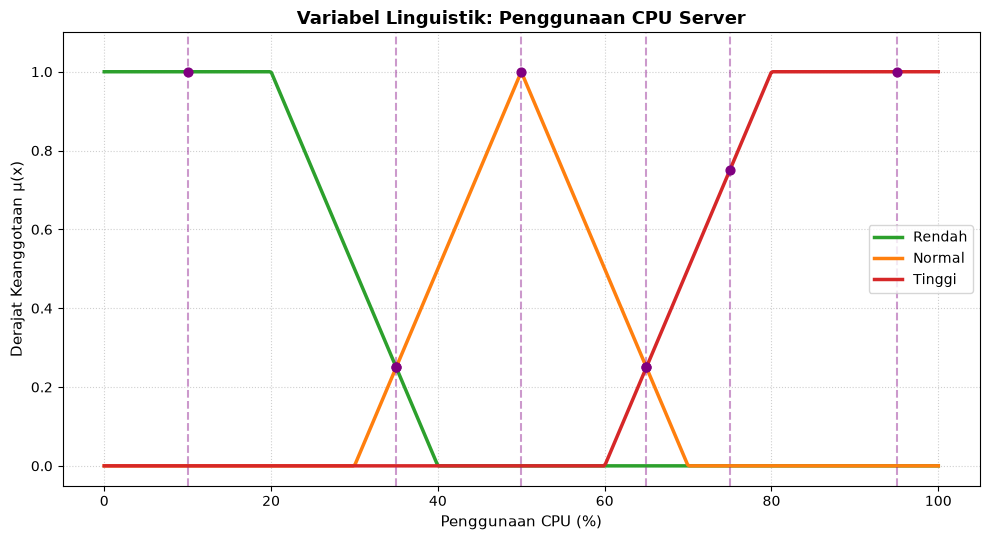

Input      μ(Rendah)    μ(Normal)    μ(Tinggi)    Label Dominan
------------------------------------------------------------------------
10 %      1.0000       0.0000       0.0000       Rendah
35 %      0.2500       0.2500       0.0000       Rendah / Normal
50 %      0.0000       1.0000       0.0000       Normal
65 %      0.0000       0.2500       0.2500       Normal / Tinggi
75 %      0.0000       0.0000       0.7500       Tinggi
95 %      0.0000       0.0000       1.0000       Tinggi


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# FUNGSI KEANGGOTAAN
# ==========================================================
def mf_rendah(x):
    """Label Rendah — bahu kiri"""
    kondisi = [
        x <= 20.0,
        (x > 20.0) & (x < 40.0),
        x >= 40.0
    ]
    pilihan = [
        1.0,
        (40.0 - x) / 20.0,
        0.0
    ]
    return np.select(kondisi, pilihan)

def mf_normal(x):
    """Label Normal — segitiga"""
    kondisi = [
        (x <= 30.0) | (x >= 70.0),
        (x > 30.0) & (x <= 50.0),
        (x > 50.0) & (x < 70.0)
    ]
    pilihan = [
        0.0,
        (x - 30.0) / 20.0,
        (70.0 - x) / 20.0
    ]
    return np.select(kondisi, pilihan)

def mf_tinggi(x):
    """Label Tinggi — bahu kanan"""
    kondisi = [
        x <= 60.0,
        (x > 60.0) & (x < 80.0),
        x >= 80.0
    ]
    pilihan = [
        0.0,
        (x - 60.0) / 20.0,
        1.0
    ]
    return np.select(kondisi, pilihan)

# ==========================================================
# DEFINISI VARIABEL LINGUISTIK
# ==========================================================
variabel_cpu = {
    "nama": "Penggunaan CPU Server",
    "satuan": "%",
    "semesta": (0.0, 100.0),
    "label": {
        "Rendah": mf_rendah,
        "Normal": mf_normal,
        "Tinggi": mf_tinggi
    }
}

# ==========================================================
# FUNGSI FUZZIFIKASI
# ==========================================================
def fuzzifikasi(nilai_crisp, variabel):
    u_min, u_max = variabel["semesta"]
    if not (u_min <= nilai_crisp <= u_max):
        raise ValueError(f"Input {nilai_crisp} di luar semesta [{u_min}, {u_max}]")
    hasil = {}
    for nama_label, fungsi_mf in variabel["label"].items():
        derajat = float(fungsi_mf(np.array([nilai_crisp]))[0])
        hasil[nama_label] = round(derajat, 4)
    return hasil

# ==========================================================
# GRAFIK FUNGSI KEANGGOTAAN
# ==========================================================
x_semesta = np.linspace(0.0, 100.0, 500)
y_rendah = mf_rendah(x_semesta)
y_normal = mf_normal(x_semesta)
y_tinggi = mf_tinggi(x_semesta)

plt.figure(figsize=(10, 5.5))
plt.plot(x_semesta, y_rendah, label='Rendah', color='#2ca02c', linewidth=2.5)
plt.plot(x_semesta, y_normal, label='Normal', color='#ff7f0e', linewidth=2.5)
plt.plot(x_semesta, y_tinggi, label='Tinggi', color='#d62728', linewidth=2.5)

# ==========================================================
# PENGUJIAN BEBERAPA NILAI
# ==========================================================
daftar_input = [10, 35, 50, 65, 75, 95]
warna_titik = 'purple'

for x_uji in daftar_input:
    derajat = fuzzifikasi(x_uji, variabel_cpu)
    plt.axvline(x=x_uji, color=warna_titik, linestyle='--', alpha=0.4)
    for lbl, dv in derajat.items():
        if dv > 0:
            plt.scatter(x_uji, dv, color=warna_titik, s=40, zorder=5)

plt.title(f'Variabel Linguistik: {variabel_cpu["nama"]}', fontsize=13, fontweight='bold')
plt.xlabel(f'Penggunaan CPU ({variabel_cpu["satuan"]})', fontsize=11)
plt.ylabel('Derajat Keanggotaan μ(x)', fontsize=11)
plt.ylim(-0.05, 1.1)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='center right', fontsize=10)
plt.tight_layout()
plt.savefig('cpu_penggunaan_fuzzy.png', dpi=300)
plt.show()

# ==========================================================
# TABEL HASIL FUZZIFIKASI
# ==========================================================
print("="*72)
print(f"{'Input':<10} {'μ(Rendah)':<12} {'μ(Normal)':<12} {'μ(Tinggi)':<12} {'Label Dominan'}")
print("-"*72)

for x in daftar_input:
    d = fuzzifikasi(x, variabel_cpu)
    # Cari label dengan nilai tertinggi
    max_val = max(d.values())
    dominan = [k for k, v in d.items() if v == max_val]
    label_dominan = " / ".join(dominan) if len(dominan) > 1 else dominan[0]
    
    print(f"{x:>2} %      {d['Rendah']:<12.4f} {d['Normal']:<12.4f} {d['Tinggi']:<12.4f} {label_dominan}")

print("="*72)